In [ ]:
# =====================================================
# METHODOLOGY SUMMARY
# =====================================================
#
# This analysis evaluates the potential for community
# energy sharing from solar-electrified health centres
# under the COVID-19 Intervention Programme in Nigeria.
#
# The objective is to identify health facilities where
# installed solar photovoltaic (PV) systems generate
# sufficient surplus electricity beyond internal health
# centre demand, and where surrounding population density
# is high enough to justify community-level electricity
# sharing.
#
# A sample of the first ten health centres was selected
# from the national intervention programme, each with an
# installed PV capacity of 50 kW.
#
# The methodology follows five major steps:
#
# 1. Site Identification
#    Health centre locations were defined using site
#    names, states, and approximate geographic
#    coordinates (latitude and longitude).
#
# 2. Estimation of Operational Demand
#    Since measured load profiles were unavailable,
#    assumed daytime operational demand values were
#    assigned based on the expected electricity needs of
#    healthcare facilities such as lighting,
#    refrigeration, medical equipment, water pumping,
#    and administrative operations.
#
# 3. Solar Surplus Calculation
#    Surplus generation was calculated as:
#
#    Surplus Generation (kW) =
#    PV Capacity (kW) − Assumed Demand (kW)
#
#    Positive surplus indicates the potential for excess
#    electricity to be shared with surrounding
#    communities.
#
# 4. Population Density Extraction
#    A national population density raster
#    (nga_pd.tif) was used to extract surrounding
#    population density values at each facility
#    location using raster sampling techniques.
#
# 5. Priority Scoring and Spatial Ranking
#    Both surplus generation and population density were
#    normalised to a 0–100 scale.
#
#    A composite Priority Score was then calculated
#    using equal weighting:
#
#    Priority Score =
#    0.5 × Surplus Score +
#    0.5 × Population Score
#
#    This allows identification of facilities with both
#    strong technical potential (solar surplus) and high
#    social impact potential (population demand).
#
# Sites were then classified into:
# - Very High Priority
# - High Priority
# - Moderate Priority
# - Low Priority
# - Very Low Priority
#
# Finally, the results were visualised spatially using
# GeoPandas, OpenStreetMap basemaps, and Matplotlib
# within Jupyter Notebook to support planning and
# decision-making for decentralised community energy
# sharing.
#
# =====================================================


Initial Data

                                          Site        State  Latitude  \
0               Federal Medical Center Yenagoa      Bayelsa    4.9267   
1  Nnamdi Azikiwe University Teaching Hospital      Anambra    6.1520   
2                     Sobi Specialist Hospital        Kwara    8.4966   
3      University of Calabar Teaching Hospital  Cross River    4.9757   
4                      Cottage Hospital Fufore      Adamawa    9.2219   
5                        State Hospital, Shaki          Oyo    8.6676   
6                      Bayara General Hospital       Bauchi   10.3158   
7         Ultra Modern Diagnostic Centre Enugu        Enugu    6.4402   
8                      Babura General Hospital       Jigawa   12.7726   
9                       General Hospital Okene         Kogi    7.5500   

   Longitude  PV_Capacity_kW  Assumed_Demand_kW  Surplus_Generation_kW  
0     6.2676              50                 35                     15  
1     6.9988              50       

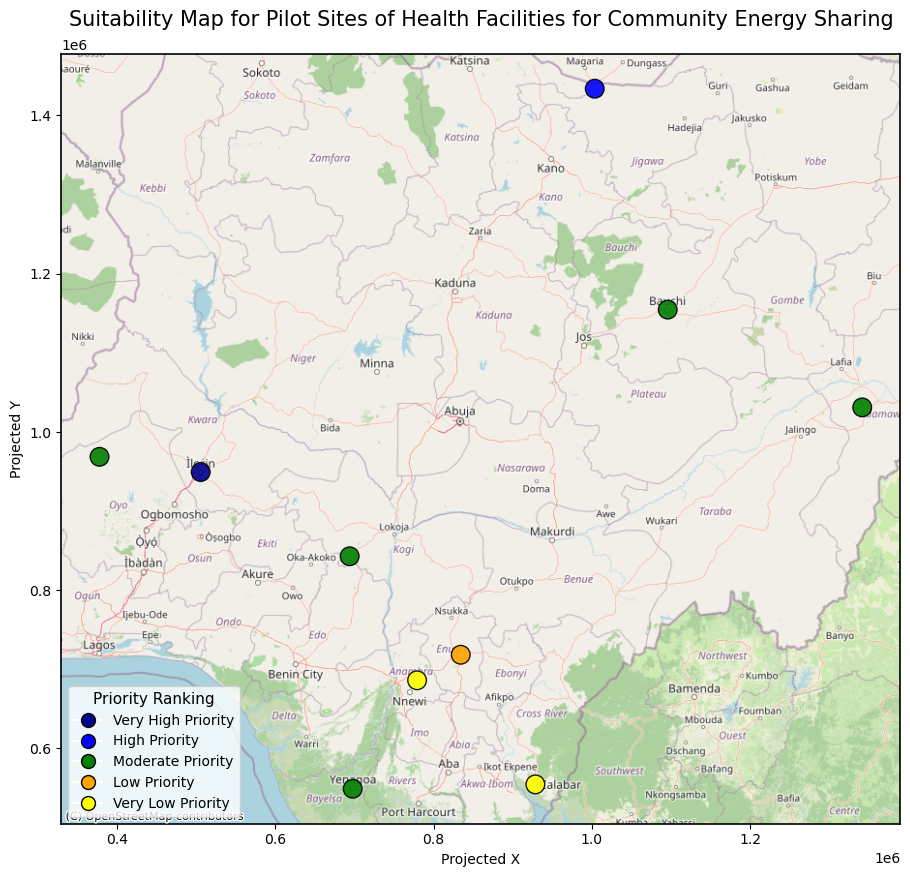


Map plotted successfully inside Jupyter Notebook.


In [14]:


# -----------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------------------------------

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D


# -----------------------------------------------------
# STEP 2: CREATE DATA FOR FIRST 10 HEALTH CENTRES
# -----------------------------------------------------

data = {
    "Site": [
        "Federal Medical Center Yenagoa",
        "Nnamdi Azikiwe University Teaching Hospital",
        "Sobi Specialist Hospital",
        "University of Calabar Teaching Hospital",
        "Cottage Hospital Fufore",
        "State Hospital, Shaki",
        "Bayara General Hospital",
        "Ultra Modern Diagnostic Centre Enugu",
        "Babura General Hospital",
        "General Hospital Okene"
    ],

    "State": [
        "Bayelsa",
        "Anambra",
        "Kwara",
        "Cross River",
        "Adamawa",
        "Oyo",
        "Bauchi",
        "Enugu",
        "Jigawa",
        "Kogi"
    ],

    # Approximate coordinates
    "Latitude": [
        4.9267,
        6.1520,
        8.4966,
        4.9757,
        9.2219,
        8.6676,
        10.3158,
        6.4402,
        12.7726,
        7.5500
    ],

    "Longitude": [
        6.2676,
        6.9988,
        4.5421,
        8.3417,
        12.0522,
        3.3936,
        9.8442,
        7.4943,
        9.0153,
        6.2333
    ],

    # Installed PV capacity
    "PV_Capacity_kW": [
        50, 50, 50, 50, 50,
        50, 50, 50, 50, 50
    ],

    # Assumed daytime operational demand
    "Assumed_Demand_kW": [
        35, 42, 30, 45, 28,
        32, 38, 40, 25, 36
    ]
}

df = pd.DataFrame(data)


# -----------------------------------------------------
# STEP 3: CALCULATE SURPLUS GENERATION
# -----------------------------------------------------

df["Surplus_Generation_kW"] = (
    df["PV_Capacity_kW"] -
    df["Assumed_Demand_kW"]
)

print("\nInitial Data\n")
print(df)


# -----------------------------------------------------
# STEP 4: CREATE GEODATAFRAME
# -----------------------------------------------------

geometry = [
    Point(xy)
    for xy in zip(
        df["Longitude"],
        df["Latitude"]
    )
]

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"
)

print("\nGeoDataFrame created successfully.\n")
print(gdf.head())


# -----------------------------------------------------
# STEP 5: LOAD POPULATION DENSITY RASTER
# -----------------------------------------------------

raster_path = Path("nga_pd.tif")

if not raster_path.exists():
    print("\nPopulation density raster not found.")
    print("Please upload: nga_pd.tif")

else:
    print(f"\nRaster found: {raster_path}")

    with rasterio.open(raster_path) as src:

        coords = list(zip(
            gdf["Longitude"],
            gdf["Latitude"]
        ))

        population_values = []

        for val in src.sample(coords):
            population_values.append(val[0])

    gdf["Population_Density"] = population_values


    # -------------------------------------------------
    # STEP 6: NORMALISE POPULATION SCORE
    # -------------------------------------------------

    pop_min = gdf["Population_Density"].min()
    pop_max = gdf["Population_Density"].max()

    if pop_max == pop_min:
        gdf["Population_Score"] = 50

    else:
        gdf["Population_Score"] = (
            (
                gdf["Population_Density"] - pop_min
            ) /
            (
                pop_max - pop_min
            )
        ) * 100


    # -------------------------------------------------
    # STEP 7: NORMALISE SURPLUS SCORE
    # -------------------------------------------------

    sur_min = gdf["Surplus_Generation_kW"].min()
    sur_max = gdf["Surplus_Generation_kW"].max()

    if sur_max == sur_min:
        gdf["Surplus_Score"] = 50

    else:
        gdf["Surplus_Score"] = (
            (
                gdf["Surplus_Generation_kW"] - sur_min
            ) /
            (
                sur_max - sur_min
            )
        ) * 100


    # -------------------------------------------------
    # STEP 8: CREATE PRIORITY SCORE
    # -------------------------------------------------

    # Equal weighting:
    # 50% Solar surplus
    # 50% Population density

    gdf["Priority_Score"] = (
        0.5 * gdf["Surplus_Score"] +
        0.5 * gdf["Population_Score"]
    ).round(2)


    # -------------------------------------------------
    # STEP 9: CLASSIFY PRIORITY LEVEL
    # -------------------------------------------------

    def classify_priority(score):
        if score >= 75:
            return "Very High Priority"
        elif score >= 55:
            return "High Priority"
        elif score >= 35:
            return "Moderate Priority"
        elif score >= 15:
            return "Low Priority"
        else:
            return "Very Low Priority"


    def assign_color(priority):
        if priority == "Very High Priority":
            return "darkblue"
        elif priority == "High Priority":
            return "blue"
        elif priority == "Moderate Priority":
            return "green"
        elif priority == "Low Priority":
            return "orange"
        else:
            return "yellow"


    gdf["Priority_Class"] = gdf[
        "Priority_Score"
    ].apply(classify_priority)

    gdf["Color"] = gdf[
        "Priority_Class"
    ].apply(assign_color)


    # -------------------------------------------------
    # STEP 10: SORT RESULTS
    # -------------------------------------------------

    gdf = gdf.sort_values(
        by="Priority_Score",
        ascending=False
    )

    print(
        "\nTOP PRIORITY SITES FOR COMMUNITY ENERGY SHARING\n"
    )

    print(
        gdf[
            [
                "Site",
                "State",
                "PV_Capacity_kW",
                "Assumed_Demand_kW",
                "Surplus_Generation_kW",
                "Population_Density",
                "Priority_Score",
                "Priority_Class"
            ]
        ]
    )


    # -------------------------------------------------
    # STEP 11: PLOT MAP WITH OPENSTREETMAP
    # -------------------------------------------------

    # Reproject for basemap compatibility
    gdf_web = gdf.to_crs(
        epsg=3857
    )

    fig, ax = plt.subplots(
        figsize=(14, 10)
    )

    # Plot points
    gdf_web.plot(
        ax=ax,
        color=gdf["Color"],
        edgecolor="black",
        markersize=180,
        alpha=0.9
    )

    # Add OpenStreetMap basemap
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik
    )

    # Title
    ax.set_title(
        "Suitability Map for Pilot Sites of Health Facilities for Community Energy Sharing",
        fontsize=15,
        pad=20
    )

    # Axis labels
    ax.set_xlabel("Projected X")
    ax.set_ylabel("Projected Y")

    # Keep frame visible
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)


    # -------------------------------------------------
    # STEP 12: CUSTOM LEGEND
    # -------------------------------------------------

    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='Very High Priority',
            markerfacecolor='darkblue',
            markeredgecolor='black',
            markersize=10
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='High Priority',
            markerfacecolor='blue',
            markeredgecolor='black',
            markersize=10
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='Moderate Priority',
            markerfacecolor='green',
            markeredgecolor='black',
            markersize=10
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='Low Priority',
            markerfacecolor='orange',
            markeredgecolor='black',
            markersize=10
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='Very Low Priority',
            markerfacecolor='yellow',
            markeredgecolor='black',
            markersize=10
        )
    ]

    ax.legend(
        handles=legend_elements,
        title="Priority Ranking",
        loc="lower left",
        frameon=True,
        fontsize=10,
        title_fontsize=11
    )

    plt.show()

    print(
        "\nMap plotted successfully inside Jupyter Notebook."
    )